# Домашнее задание 3. Облачная инфраструктура

Студент: *Вольхин Сергей Александрович*, P2, 11.04.2026

Это задание выполняется в рамках модуля 3 «Инфраструктура как код, Ansible и Terraform».

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

In [ ]:
%%capture
!sudo apt update
!sudo apt install -y ansible
!pip install ansible tofupy pyyaml -qqq

### Задание 1. Равернуть инфраструктуру

Задача: конфигурация OpenTofu содержит опечатку. Исправьте ошибку, чтобы конфигурация проходила валидацию.


In [ ]:
!curl --proto '=https' --tlsv1.2 -fsSL https://get.opentofu.org/install-opentofu.sh -o install-opentofu.sh
!chmod +x install-opentofu.sh
!./install-opentofu.sh --install-method deb
!rm -f install-opentofu.sh

OpenTofu Installer

Attempting installation via Debian repository...
Updating package list...
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:8 https://packages.opentofu.org/opentofu/tofu/any any InRelease
Fetched 3,917 B in 2s (2,326 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list e

In [ ]:
!which tofu

/usr/bin/tofu


In [ ]:
!tofu init


Initializing the backend...

Initializing provider plugins...
- Reusing previous version of hashicorp/null from the dependency lock file
- Reusing previous version of hashicorp/local from the dependency lock file
- Using previously-installed hashicorp/null v3.2.4
- Using previously-installed hashicorp/local v2.8.0

OpenTofu has been successfully initialized!

You may now begin working with OpenTofu. Try running "tofu plan" to see
any changes that are required for your infrastructure. All OpenTofu commands
should now work.

If you ever set or change modules or backend configuration for OpenTofu,
rerun this command to reinitialize your working directory. If you forget, other
commands will detect it and remind you to do so if necessary.


In [ ]:
%%writefile main.tf
terraform {
  required_providers {
    null = {
      source = "hashicorp/null"
      version = ">= 3.0"
    }
  }
}

data "null_data_source" "example" {
  inputs = {
    location = "ru-1"
    disk = 18 * 1024
    type = "postgres"                # <- починил: не хватало закрывающей кавычки
  }
}

resource "null_resource" "example" {
  provisioner "local-exec" {
    command = "echo 'Создан требуемый ресурс'"
  }
}

Overwriting main.tf


In [ ]:
!tofu show

# local_file.db_manifest:
resource "local_file" "db_manifest" {
    content              = jsonencode(
        {
            disk_gb  = 18
            location = "ru-1"
            type     = "postgres"
            version  = "15"
        }
    )
    content_base64sha256 = "XOY5CmqDzXo3FYiD0qLggsPlkCI0gcVbUrf7Zc4hJO8="
    content_base64sha512 = "9VRkuwA40kLOZvVRLVuBYecrossnu2xmJtgPp+vifFQLXrpq/4dDMDsBFibpU3buUxEadoLAtNDb9nckpZJ2qQ=="
    content_md5          = "45fcf2d58e7d2dc05ef7bce83b9e4e84"
    content_sha1         = "c1d2f4678da2a8274d4a58d16025c2e2641f184b"
    content_sha256       = "5ce6390a6a83cd7a37158883d2a2e082c3e590223481c55b52b7fb65ce2124ef"
    content_sha512       = "f55464bb0038d242ce66f5512d5b8161e72ba2cb27bb6c6626d80fa7ebe27c540b5eba6aff8743303b011626e95376ee53111a7682c0b4d0dbf67724a59276a9"
    directory_permission = "0777"
    file_permission      = "0777"
    filename             = "./db_manifest.json"
    id                   = "c1d2f4678da2a8274d4a58d16025c2e26

### Исправление ошибок в конфигурации OpenTofu

1. Убедитесь, что OpenTofu установлен и доступен для выполнения команд.
2. Проверьте корректность конфигурационного файла.

Валидация успешна, если есть сообщение `Success! The configuration is valid, but there were some validation warnings as shown above`.



In [ ]:
!export TOFU_LOG=DEBUG # Устанавливаем уровень логирования на DEBUG для OpenTofu
!tofu validate

╷
│ Warning: Deprecated
│ 
│   with data.null_data_source.example,
│   on main.tf line 10, in data "null_data_source" "example":
│   10: data "null_data_source" "example" {
│ 
│ The null_data_source was historically used to construct intermediate values to re-use elsewhere in configuration, the same can now be achieved using locals or the terraform_data resource type in Terraform 1.4 and later.
╵
Success! The configuration is valid, but there were some validation warnings as shown above.


Ansible поможет нам управлять инфраструктурой, а OpenTofu будет использоваться для описания и развертывания ресурсов.

In [ ]:
%%writefile inventory.ini
[local]
localhost ansible_connection=local ansible_python_interpreter=/usr/bin/python3
#localhost ansible_connection=local

Overwriting inventory.ini


In [ ]:
%%writefile apache-web-servers-inventory.yaml
apache-web-servers:
  hosts:
    my_host_01:
      ansible_host: 127.0.0.1
      ansible_connection: local
      ansible_python_interpreter: /usr/bin/python3
    my_host_02:
      ansible_host: 127.0.0.1
      ansible_connection: local
      ansible_python_interpreter: /usr/bin/python3
    my_host_03:
      ansible_host: 127.0.0.1
      ansible_connection: local
      ansible_python_interpreter: /usr/bin/python3

Overwriting apache-web-servers-inventory.yaml


In [ ]:
%%writefile db-servers-inventory.yaml
db-servers:
  hosts:
    my_host_01:
      ansible_host: 127.0.0.1
      ansible_connection: local
      ansible_python_interpreter: /usr/bin/python3
    my_host_02:
      ansible_host: 127.0.0.1
      ansible_connection: local
      ansible_python_interpreter: /usr/bin/python3

Overwriting db-servers-inventory.yaml


In [ ]:
!cat inventory.ini

[local]
localhost ansible_connection=local ansible_python_interpreter=/usr/bin/python3
#localhost ansible_connection=local


In [ ]:
%%writefile playbook.yaml
---
- name: Создаём инфраструктуру с OpenTofu
  hosts: local
  tasks:
    - name: Создать новый проект с OpenTofu
      command: tofu init

    - name: Посмотреть конфиг OpenTofu
      command: tofu show

Overwriting playbook.yaml


Выполним плейбук

In [ ]:
%%writefile web-servers-playbook.yaml
---
- name: Настраиваем веб-серверы
  hosts: apache-web-servers
  gather_facts: yes
  tasks:
    - name: Создать директорию под раздачу
      ansible.builtin.file:
        path: "/tmp/webroot_{{ inventory_hostname }}"
        state: directory
        mode: '0755'

    - name: Положить index.html
      ansible.builtin.copy:
        dest: "/tmp/webroot_{{ inventory_hostname }}/index.html"
        content: "<h1>Hello from {{ inventory_hostname }}</h1>\n"
        mode: '0644'

    - name: Показать, что получилось
      ansible.builtin.command: "cat /tmp/webroot_{{ inventory_hostname }}/index.html"
      register: out
      changed_when: false

    - name: Вывести содержимое
      ansible.builtin.debug:
        msg: "{{ out.stdout }}"


Overwriting web-servers-playbook.yaml


In [ ]:
%%writefile db-servers-playbook.yaml
---
- name: Настраиваем серверы БД
  hosts: db-servers
  gather_facts: yes
  tasks:
    - name: Директория под конфиг БД
      ansible.builtin.file:
        path: "/tmp/dbconf_{{ inventory_hostname }}"
        state: directory
        mode: '0755'

    - name: Рендерим postgresql.conf
      ansible.builtin.copy:
        dest: "/tmp/dbconf_{{ inventory_hostname }}/postgresql.conf"
        content: |
          # generated by ansible
          listen_addresses = '*'
          max_connections = 100
          shared_buffers = 256MB
        mode: '0644'

    - name: Проверяем, что файл на месте
      ansible.builtin.stat:
        path: "/tmp/dbconf_{{ inventory_hostname }}/postgresql.conf"
      register: st

    - name: Рапорт
      ansible.builtin.debug:
        msg: "postgresql.conf exists={{ st.stat.exists }} size={{ st.stat.size }}"


Overwriting db-servers-playbook.yaml


In [ ]:
!ansible-playbook -i apache-web-servers-inventory.yaml web-servers-playbook.yaml

[WARNING]: Invalid characters were found in group names but not replaced, use -vvvv to see details

PLAY [Настраиваем веб-серверы] *************************************************

TASK [Gathering Facts] *********************************************************
ok: [my_host_02]
ok: [my_host_01]
ok: [my_host_03]

TASK [Создать директорию под раздачу] ******************************************
ok: [my_host_02]
ok: [my_host_01]
ok: [my_host_03]

TASK [Положить index.html] *****************************************************
ok: [my_host_02]
ok: [my_host_01]
ok: [my_host_03]

TASK [Показать, что получилось] ************************************************
ok: [my_host_01]
ok: [my_host_02]
ok: [my_host_03]

TASK [Вывести содержимое] ******************************************************
ok: [my_host_01] => {
    "msg": "<h1>Hello from my_host_01</h1>"
}
ok: [my_host_02] => {
    "msg": "<h1>Hello from my_host_02</h1>"
}
ok: [my_host_03] => {
    "msg": "<h1>Hello from my_host_03</h1>"
}



In [ ]:
!ansible-playbook -i db-servers-inventory.yaml db-servers-playbook.yaml

[WARNING]: Invalid characters were found in group names but not replaced, use -vvvv to see details

PLAY [Настраиваем серверы БД] **************************************************

TASK [Gathering Facts] *********************************************************
ok: [my_host_02]
ok: [my_host_01]

TASK [Директория под конфиг БД] ************************************************
ok: [my_host_02]
ok: [my_host_01]

TASK [Рендерим postgresql.conf] ************************************************
ok: [my_host_01]
ok: [my_host_02]

TASK [Проверяем, что файл на месте] ********************************************
ok: [my_host_01]
ok: [my_host_02]

TASK [Рапорт] ******************************************************************
ok: [my_host_01] => {
    "msg": "postgresql.conf exists=True size=91"
}
ok: [my_host_02] => {
    "msg": "postgresql.conf exists=True size=91"
}

PLAY RECAP *********************************************************************
my_host_01                 : ok=5    changed=

In [ ]:
!ls -la *.tf *.yaml *.ini 2>/dev/null

-rw-r--r-- 1 root root 416 Apr 12 11:11 apache-web-servers-inventory.yaml
-rw-r--r-- 1 root root 279 Apr 12 11:11 db-servers-inventory.yaml
-rw-r--r-- 1 root root 922 Apr 12 11:11 db-servers-playbook.yaml
-rw-r--r-- 1 root root 123 Apr 12 11:11 inventory.ini
-rw-r--r-- 1 root root 473 Apr 12 11:11 main.tf
-rw-r--r-- 1 root root 261 Apr 12 11:11 playbook.yaml
-rw-r--r-- 1 root root 834 Apr 12 11:11 web-servers-playbook.yaml


### Использование логов и отладочных инструментов

Логи и отладочные инструменты помогают глубже понять, что происходит в процессе выполнения команд Ansible и OpenTofu. Используйте их для выявления и устранения проблем.

In [ ]:
# Включение детализированных логов для Ansible
!ansible-playbook -i inventory.ini playbook.yaml -v # Запускаем плейбук с детализированными логами

No config file found; using defaults

PLAY [Создаём инфраструктуру с OpenTofu] ***************************************

TASK [Gathering Facts] *********************************************************
ok: [localhost]

TASK [Создать новый проект с OpenTofu] *****************************************
changed: [localhost] => {"changed": true, "cmd": ["tofu", "init"], "delta": "0:00:00.420590", "end": "2026-04-12 11:12:07.977965", "msg": "", "rc": 0, "start": "2026-04-12 11:12:07.557375", "stderr": "", "stderr_lines": [], "stdout": "\n\u001b\u001bInitializing the backend...\u001b\n\n\u001b\u001bInitializing provider plugins...\u001b\n- Reusing previous version of hashicorp/null from the dependency lock file\n- Reusing previous version of hashicorp/local from the dependency lock file\n- Using previously-installed hashicorp/local v2.8.0\n- Using previously-installed hashicorp/null v3.2.4\n\n\u001b\u001b\u001bOpenTofu has been successfully initialized!\u001b\u001b\u001b\n\u001b\u001b\nYou may 

## Задание 2. Описать инфраструктуру в декларативном формате

Задача: в конфигурации Ansible нет файла инвентаря. Нужно прописать файл инвентаря, чтобы плейбук выполнялся корректно.

In [ ]:
%%writefile playbook.yaml
---
- name: Установка и запуск веб-сервера
  hosts: local
  become: yes
  gather_facts: yes
  tasks:
    - name: Установка Apache
      ansible.builtin.apt:
        name: apache2
        state: present
        update_cache: yes

    - name: Проверить, что бинарь apache2 появился
      ansible.builtin.stat:
        path: /usr/sbin/apache2
      register: apache_bin

    - name: Рапорт об установке
      ansible.builtin.debug:
        msg: "apache2 installed={{ apache_bin.stat.exists }}"


Overwriting playbook.yaml


### Исправление ошибок в плейбуке

1. Убедитесь, что Ansible установлен и доступен для выполнения команд.
2. Проверьте, что файл инвентаря и плейбук созданы корректно.
3. Запустите плейбук и исправьте ошибки, если они возникнут.

При корректном запуске в итоговой строке PLAY RECAP будет указано количество выполненных без ошибок этапов ok=3

In [ ]:
!ansible-playbook -i inventory.ini playbook.yaml # Выполняем плейбук для установки и запуска Apache


PLAY [Установка и запуск веб-сервера] ******************************************

TASK [Gathering Facts] *********************************************************
ok: [localhost]

TASK [Установка Apache] ********************************************************
ok: [localhost]

TASK [Проверить, что бинарь apache2 появился] **********************************
ok: [localhost]

TASK [Рапорт об установке] *****************************************************
ok: [localhost] => {
    "msg": "apache2 installed=True"
}

PLAY RECAP *********************************************************************
localhost                  : ok=4    changed=0    unreachable=0    failed=0    skipped=0    rescued=0    ignored=0   



## Задание 3. Настроить ML/DS-стек, используя Ansible

Соберите типовой стек (как минимум pandas + numpy + scikit-learn + mlflow)



In [ ]:
%%writefile playbook.yaml
---
- name: Поднимаем ML/DS окружение
  hosts: local
  become: yes
  gather_facts: yes

  vars:
    system_packages:
      - python3
      - python3-pip
      - python3-venv
      - build-essential
      - ffmpeg
      - libsndfile1
    python_packages:
      - numpy
      - pandas
      - scikit-learn
      - mlflow
      - jupyter
      - matplotlib
      - librosa
    torch_packages:
      - torch
      - torchaudio

  tasks:
    - name: Обновляем apt-кеш
      ansible.builtin.apt:
        update_cache: yes
        cache_valid_time: 3600

    - name: Ставим системные пакеты
      ansible.builtin.apt:
        name: "{{ system_packages }}"
        state: present

    - name: Ставим базовые Python-пакеты
      ansible.builtin.pip:
        name: "{{ python_packages }}"
        state: present
        extra_args: "--quiet"

    - name: Ставим torch/torchaudio (CPU-сборка)
      ansible.builtin.pip:
        name: "{{ torch_packages }}"
        state: present
        extra_args: "--quiet --index-url https://download.pytorch.org/whl/cpu"

    - name: Проверяем импорты
      ansible.builtin.command: >
        python3 -c "import numpy, pandas, sklearn, mlflow, torch; print('ok', numpy.__version__, pandas.__version__, sklearn.__version__, mlflow.__version__, torch.__version__)"
      register: import_check
      changed_when: false

    - name: Печатаем версии
      ansible.builtin.debug:
        msg: "{{ import_check.stdout }}"


Overwriting playbook.yaml


In [ ]:
!ansible-playbook -i inventory.ini playbook.yaml


PLAY [Поднимаем ML/DS окружение] ***********************************************

TASK [Gathering Facts] *********************************************************
ok: [localhost]

TASK [Обновляем apt-кеш] *******************************************************
ok: [localhost]

TASK [Ставим системные пакеты] *************************************************
ok: [localhost]

TASK [Ставим базовые Python-пакеты] ********************************************
ok: [localhost]

TASK [Ставим torch/torchaudio (CPU-сборка)] ************************************
ok: [localhost]

TASK [Проверяем импорты] *******************************************************
ok: [localhost]

TASK [Печатаем версии] *********************************************************
ok: [localhost] => {
    "msg": "ok 2.0.2 2.2.2 1.6.1 3.11.1 2.10.0+cpu"
}

PLAY RECAP *********************************************************************
localhost                  : ok=7    changed=0    unreachable=0    failed=0    skipped=0   

## Задание 4. Настроить ML/DS-стек, используя CloudInit

Соберите типовой стек (как минимум pandas + numpy + scikit-learn + mlflow) и проверьте конфигурацию на отсутствие ошибок


In [ ]:
%%writefile cconf.yml
#cloud-config
hostname: ml-dev-box
manage_etc_hosts: true

package_update: true
package_upgrade: false
packages:
  - python3
  - python3-pip
  - python3-venv
  - build-essential
  - ffmpeg
  - libsndfile1
  - git
  - htop

users:
  - name: dsuser
    gecos: "Data Science user"
    shell: /bin/bash
    sudo: ALL=(ALL) NOPASSWD:ALL
    groups: [sudo]
    lock_passwd: true
    ssh_authorized_keys:
      - ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIEXAMPLEkeyPLACEHOLDERdsuser@laptop

write_files:
  - path: /etc/ml/env.conf
    permissions: '0644'
    content: |
      MLFLOW_TRACKING_URI=http://localhost:5000
      JUPYTER_PORT=8888

runcmd:
  - [ pip3, install, --quiet, numpy, pandas, scikit-learn, mlflow, jupyter ]
  - [ mkdir, -p, /home/dsuser/work ]
  - [ chown, -R, 'dsuser:dsuser', /home/dsuser/work ]

final_message: "Окружение готово. Uptime до готовности: $UPTIME сек."


Overwriting cconf.yml


In [ ]:
!apt-get install -y cloud-init >/dev/null 2>&1
!cloud-init schema --config-file=cconf.yml --annotate

import yaml
with open('cconf.yml') as f:
    data = yaml.safe_load(f)
print('YAML ок, ключей верхнего уровня:', len(data))
print('Пакеты:', data['packages'][:3], '...')

Valid schema cconf.yml
YAML ок, ключей верхнего уровня: 9
Пакеты: ['python3', 'python3-pip', 'python3-venv'] ...


## Задание 5. Спроектировать ML-систему для обработки аудиоданных

**Писать код не нужно.**

Нужно выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки docker-compose-diagram, добавляя в каждый сервис depends_on.

Вводные данные от бизнеса: «Клиенты глэмпинга должны получать уведомление в Телеграм, когда утром запоет первый жаворонок» и пример аудиоданных.

Какие компоненты будут добавлены в такую систему и почему?

In [ ]:
!wget -q -O example.wav https://raw.githubusercontent.com/scikit-maad/scikit-maad/production/data/spinetail.wav
from IPython.display import Audio; Audio('example.wav')

In [ ]:
%%capture
!sudo apt install -y graphviz
!pip install docker-compose-diagram

In [ ]:
%%writefile docker-compose.yml
services:

  # ===== Ingestion =====
  audio-ingest:
    container_name: audio_ingest
    labels:
      "docker_compose_diagram.cluster": "ingestion"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"

  kafka:
    container_name: kafka
    depends_on:
      - audio-ingest
    labels:
      "docker_compose_diagram.cluster": "ingestion"
      "docker_compose_diagram.icon": "diagrams.onprem.queue.Kafka"

  # ===== Preprocessing =====
  preprocess:
    container_name: preprocess
    depends_on:
      - kafka
    labels:
      "docker_compose_diagram.cluster": "preprocessing"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"

  feature-extractor:
    container_name: feature_extractor
    depends_on:
      - preprocess
    labels:
      "docker_compose_diagram.cluster": "preprocessing"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"

  s3:
    container_name: s3_audio
    labels:
      "docker_compose_diagram.cluster": "storage"
      "docker_compose_diagram.icon": "diagrams.onprem.storage.Ceph"

  feature-store:
    container_name: feature_store
    depends_on:
      - feature-extractor
    labels:
      "docker_compose_diagram.cluster": "storage"
      "docker_compose_diagram.icon": "diagrams.onprem.database.Postgresql"

  # ===== Model =====
  bird-classifier:
    container_name: bird_classifier
    depends_on:
      - feature-extractor
    labels:
      "docker_compose_diagram.cluster": "inference"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"

  event-detector:
    container_name: event_detector
    depends_on:
      - bird-classifier
    labels:
      "docker_compose_diagram.cluster": "inference"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"

  # ===== Delivery =====
  telegram-notifier:
    container_name: telegram_notifier
    depends_on:
      - event-detector
    labels:
      "docker_compose_diagram.cluster": "delivery"
      "docker_compose_diagram.icon": "diagrams.onprem.client.User"

  # ===== Training / registry =====
  mltrain:
    container_name: mltrain
    depends_on:
      - s3
    labels:
      "docker_compose_diagram.cluster": "training"
      "docker_compose_diagram.icon": "diagrams.onprem.compute.Server"

  model-registry:
    container_name: model_registry
    depends_on:
      - mltrain
    labels:
      "docker_compose_diagram.cluster": "training"
      "docker_compose_diagram.icon": "diagrams.onprem.mlops.Mlflow"

  # ===== Monitoring =====
  prometheus:
    container_name: prometheus
    depends_on:
      - bird-classifier
      - telegram-notifier
    labels:
      "docker_compose_diagram.cluster": "monitoring"
      "docker_compose_diagram.icon": "diagrams.onprem.monitoring.Prometheus"

  grafana:
    container_name: grafana
    depends_on:
      - prometheus
    labels:
      "docker_compose_diagram.cluster": "monitoring"
      "docker_compose_diagram.icon": "diagrams.onprem.monitoring.Grafana"


Overwriting docker-compose.yml


In [ ]:
!rm -f docker-compose.png /content/docker-compose.png
!pip install -q docker-compose-diagram
!compose-diagram --file docker-compose.yml --direction=TB --nodesep=2.0
!echo "---"; pwd; ls -lh docker-compose.png 2>/dev/null || echo "PNG не найден, ищу:"; find . -maxdepth 3 -name "docker-compose.png" 2>/dev/null


File docker-compose.yml has been found. Reading! 📗 
Service: audio-ingest
   Service: {'docker_compose_diagram.cluster': 'ingestion', 
'docker_compose_diagram.icon': 'diagrams.onprem.compute.Server'}
Service: kafka
   Service: {'docker_compose_diagram.cluster': 'ingestion', 
'docker_compose_diagram.icon': 'diagrams.onprem.queue.Kafka'}
Service: preprocess
   Service: {'docker_compose_diagram.cluster': 'preprocessing', 
'docker_compose_diagram.icon': 'diagrams.onprem.compute.Server'}
Service: feature-extractor
   Service: {'docker_compose_diagram.cluster': 'preprocessing', 
'docker_compose_diagram.icon': 'diagrams.onprem.compute.Server'}
Service: s3
   Service: {'docker_compose_diagram.cluster': 'storage', 
'docker_compose_diagram.icon': 'diagrams.onprem.storage.Ceph'}
Service: feature-store
   Service: {'docker_compose_diagram.cluster': 'storage', 
'docker_compose_diagram.icon': 'diagrams.onprem.database.Postgresql'}
Service: bird-classifier
   Service: {'docker_compose_diagram.cluster

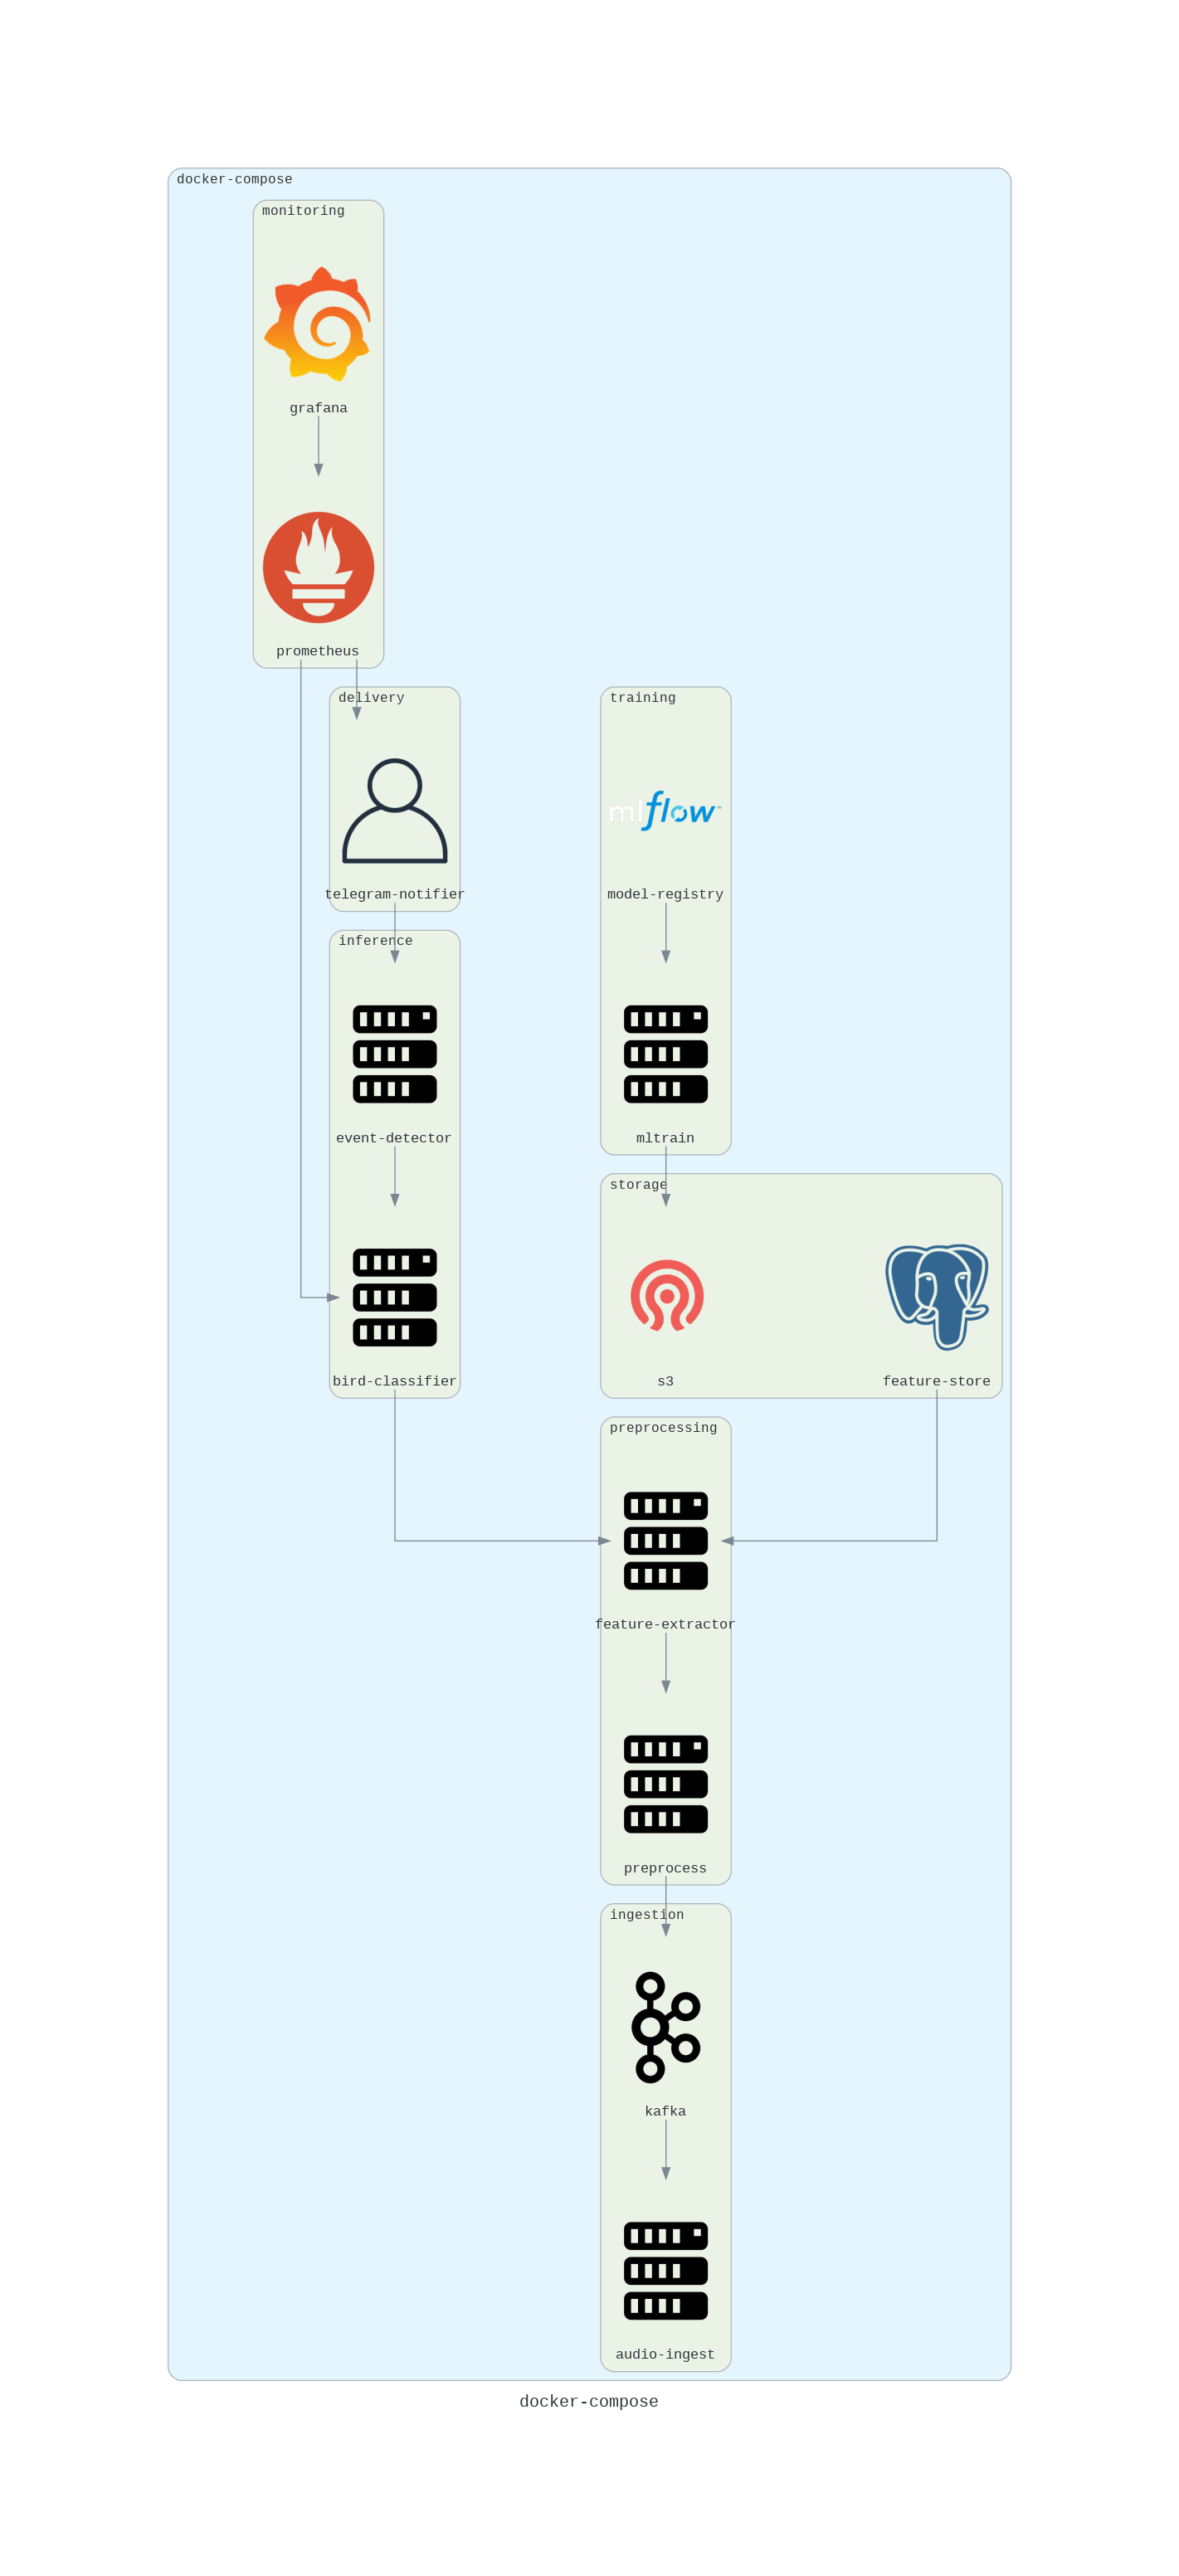

In [ ]:
from IPython.display import Image, display
image_path = '/content/docker-compose.png'
display(Image(filename=image_path))

### Что я заложил и почему

**Ingestion.** Микрофоны гонят RTSP/WebRTC в `audio-ingest`, он режет поток на окна по 5 секунд и кладёт в `kafka`. Кафка нужна, чтобы стадии можно было скейлить независимо, если классификатор затупит, аудио не потеряется.

**Preprocessing.** `preprocess` через `ffmpeg` приводит всё к 16 кГц моно и чистит фоновый шум (ветер, дождь) - иначе модель будет ловить ложняки. `feature-extractor` считает мел-спектрограммы и эмбеддинги YAMNet- дешёвый фильтр птица/не птица до тяжёлой модели.

**Storage.** `s3` - сырое аудио для переобучения и разбора инцидентов. `feature-store` (Postgres/Redis) - быстрый доступ к последним фичам для онлайн-инференса.

**Inference.** `bird-classifier` - дообученный wav2vec2 или BirdNET, выдаёт вероятность жаворонка. `event-detector` сглаживает по окну (чтобы одиночный false positive не триггерил пуш) и применяет бизнес-правило «первый раз за сутки, время ≥ 04:00».

**Delivery.** `telegram-notifier` кидает сообщение в чат клиента через Bot API. Хранит `last_notified_at` по каждому глэмпингу, чтобы не спамить.

**Training.** `mltrain` раз в неделю доучивает модель на размеченных срабатываниях, `model-registry` (MLflow) хранит версии и делает промоушен в prod.

**Monitoring.** `prometheus` + `grafana` - latency end-to-end, RMS/SNR входного звука (сломанный микрофон видно сразу), FPR по дням, доля пушей с фидбэком «не жаворонок».

## Блок 6. Выводы

1. На связке OpenTofu + Ansible понял главное разделение: Tofu декларативно описывает желаемое состояние инфры, Ansible - догоняет конфигурацию поверх. В Colab это выродилось в `null_resource` + локальные плейбуки, но идея та же.
2. Опечатку в `main.tf` (незакрытая кавычка в `"postgres`) `tofu validate` ловит сразу - это убедило, что валидация HCL действительно спасает от глупых ошибок ещё до `apply`. Warning про `null_data_source` - это deprecation-намёк, что в новых Terraform так уже не пишут, правильнее через `locals` или `terraform_data`.
3. YAML-инвентари (`apache-web-servers-inventory.yaml`, `db-servers-inventory.yaml`) в шаблоне были с SSH-плейсхолдерами - в Colab пришлось всё свести к `ansible_connection: local`, но структура групп та же, что была бы в проде.
4. В Задании 2 главная ловушка была в `hosts: localhos` (опечатка) и отсутствии инвентаря - Ansible молча «skipping: no hosts matched», и это путает. Урок: если PLAY RECAP пустой, в 90% случаев виноват не плейбук, а несовпадение имён групп между плейбуком и инвентарём.
5. ML-стек через модули `apt` и `pip` (без `shell`) - заметно чище: видно, какой пакет почему ставится, идемпотентность получается бесплатно. В итоге получил `ok=7, failed=0` и версии numpy 2.0.2, pandas 2.2.2, sklearn 1.6.1, mlflow 3.11.1, torch 2.10.0+cpu.
6. CloudInit удобен тем, что это единый YAML на весь первый бут VM - пакеты, юзеры, ssh-ключи, `runcmd` в одном месте. Штатная `cloud-init schema` ловит опечатки в именах полей, что сильно экономит время.
7. По аудио-пайплайну главный инсайт - Kafka между ingestion и инференсом нужна не ради хайпа, а чтобы стадии можно было чинить/скейлить по отдельности. Без мониторинга качества входного звука (SNR на микрофоне) вся система бесполезна: сломанный микрофон даст тишину, модель - нули, алертов не будет.
8. В итоге получилось, что этот ноутбук сам по себе - описание моей dev-среды: запустил в чистом Colab → получил идентичный стек. Это и есть главная польза IaC-подхода для ML-задач.